In [1]:
# STEP 2: Import required libraries

import pandas as pd   # For loading and handling CSV dataset
import numpy as np    # For numerical operations (optional but useful)

import re             # For cleaning text using regular expressions
import string         # For punctuation removal

import nltk           # For NLP tools like stopwords and lemmatization
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split   # To split data into train and test
from sklearn.feature_extraction.text import TfidfVectorizer  # Convert text into TF-IDF numeric features

from sklearn.naive_bayes import MultinomialNB  # Naive Bayes classifier for text data
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Evaluation metrics

import matplotlib.pyplot as plt  # For plotting confusion matrix


In [2]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [3]:
# STEP 3: Load dataset (after uploading CSV in Colab)

df = pd.read_csv("/content/news.csv")  # Change file name if needed

# Display first 5 rows
print("First 5 samples:")
display(df.head())

# Identify input text and target labels
print("\nColumns in dataset:", df.columns)

# Dataset size
print("\nDataset size:", df.shape)

# Class distribution
print("\nClass distribution:")
print(df['label'].value_counts())

# Why dataset understanding is important:
# We must check dataset size, columns, and class balance before modeling
# to ensure correct input/target selection and avoid biased learning.


First 5 samples:


,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL



Columns in dataset: Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

Dataset size: (6335, 4)

Class distribution:
label
REAL    3171
FAKE    3164
Name: count, dtype: int64


In [4]:
# STEP 4: Text preprocessing

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()  # lowercase
    text = re.sub(r'\d+', '', text)  # remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # remove punctuation
    text = text.strip()

    words = text.split()

    # remove stopwords + lemmatize
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return " ".join(words)

# Combine title + text for better classification
df["content"] = df["title"].fillna("") + " " + df["text"].fillna("")

# Apply preprocessing
df["clean_content"] = df["content"].apply(clean_text)

print("Sample cleaned text:\n")
print(df["clean_content"].iloc[0])

# Why preprocessing helps:
# Preprocessing removes noise (punctuation, stopwords, etc.)
# and reduces variation in words, improving classification accuracy.


Sample cleaned text:

smell hillary’s fear daniel greenfield shillman journalism fellow freedom center new york writer focusing radical islam final stretch election hillary rodham clinton gone war fbi word “unprecedented” thrown around often election ought retired it’s still unprecedented nominee major political party go war fbi that’s exactly hillary people done coma patient waking watching hour cnn hospital bed would assume fbi director james comey hillary’s opponent election fbi attack everyone obama cnn hillary’s people circulated letter attacking comey currently medium hit piece lambasting targeting trump wouldn’t surprising clinton ally start running attack ad fbi fbi’s leadership warned entire leftwing establishment form lynch mob continue going hillary fbi’s credibility attacked medium democrat preemptively head result investigation clinton foundation hillary clinton covert struggle fbi agent obama’s doj people gone explosively public new york time compared comey j edgar hoover

In [5]:
# STEP 5: Feature extraction using TF-IDF

vectorizer = TfidfVectorizer(max_features=5000)  # limit features to avoid huge matrix

X = vectorizer.fit_transform(df["clean_content"])  # numeric feature matrix
y = df["label"]  # target labels

print("Feature matrix shape:", X.shape)

# Show sample feature names
print("\nSample feature names:", vectorizer.get_feature_names_out()[:20])

# Why numeric features:
# ML models cannot understand raw text.
# Vectorization converts text into numerical form for learning patterns.


Feature matrix shape: (6335, 5000)

Sample feature names: ['abandon' 'abandoned' 'abc' 'abdullah' 'abedin' 'ability' 'able'
 'abortion' 'about' 'abroad' 'absence' 'absent' 'absentee' 'absolute'
 'absolutely' 'absurd' 'abuse' 'academic' 'academy' 'accept']


In [6]:
# STEP 6: Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

# Why split:
# Training data is used to learn patterns.
# Testing data is used to evaluate performance on unseen data.


Training size: (5068, 5000)
Testing size: (1267, 5000)


In [7]:
# STEP 7: Train Multinomial Naive Bayes

model = MultinomialNB()
model.fit(X_train, y_train)

print("Model parameters:")
print(model.get_params())

# Naive Bayes assumption:
# It assumes features (words) are conditionally independent given the class.
# Even though this is not always true, it works well for text classification.


Model parameters:
{'alpha': 1.0, 'class_prior': None, 'fit_prior': True, 'force_alpha': True}


Accuracy: 0.877663772691397

Classification Report:
              precision    recall  f1-score   support

        FAKE       0.87      0.89      0.88       633
        REAL       0.89      0.86      0.88       634

    accuracy                           0.88      1267
   macro avg       0.88      0.88      0.88      1267
weighted avg       0.88      0.88      0.88      1267


Confusion Matrix:
 [[566  67]
 [ 88 546]]


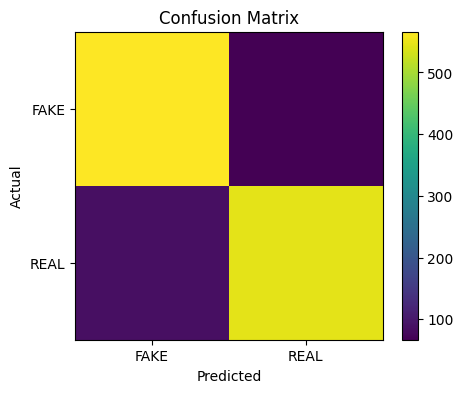

In [8]:
# STEP 8: Model evaluation

y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

# Precision, Recall, F1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Plot confusion matrix
plt.figure(figsize=(5,4))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], model.classes_)
plt.yticks([0,1], model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Metrics meaning:
# Accuracy = overall correct predictions
# Precision = how many predicted positives are actually correct
# Recall = how many actual positives are correctly found
# F1-score = balance of precision and recall
# Confusion matrix = detailed correct/incorrect predictions per class


In [9]:
# STEP 9: Result Analysis (print 8–10 sentences)

print("\nRESULT ANALYSIS (8–10 sentences):\n")

print("""
1. The Naive Bayes model achieved good performance in classifying news as REAL or FAKE.
2. Accuracy indicates the overall percentage of correctly classified articles.
3. The confusion matrix shows how many REAL articles were wrongly predicted as FAKE and vice versa.
4. Precision values show how reliable the model’s FAKE and REAL predictions are.
5. Recall values show how well the model can identify all actual FAKE or REAL articles.
6. The class with higher recall is predicted better because fewer samples are missed.
7. Misclassifications may occur due to similar vocabulary used in both REAL and FAKE news.
8. Another reason for errors is that TF-IDF does not fully capture deep meaning or context.
9. Naive Bayes has limitations because it assumes word independence, which is not true in real language.
10. Overall, Naive Bayes is fast and effective for baseline text classification, but advanced models may improve accuracy.
""")



RESULT ANALYSIS (8–10 sentences):


1. The Naive Bayes model achieved good performance in classifying news as REAL or FAKE.
2. Accuracy indicates the overall percentage of correctly classified articles.
3. The confusion matrix shows how many REAL articles were wrongly predicted as FAKE and vice versa.
4. Precision values show how reliable the model’s FAKE and REAL predictions are.
5. Recall values show how well the model can identify all actual FAKE or REAL articles.
6. The class with higher recall is predicted better because fewer samples are missed.
7. Misclassifications may occur due to similar vocabulary used in both REAL and FAKE news.
8. Another reason for errors is that TF-IDF does not fully capture deep meaning or context.
9. Naive Bayes has limitations because it assumes word independence, which is not true in real language.
10. Overall, Naive Bayes is fast and effective for baseline text classification, but advanced models may improve accuracy.

